In [ ]:
# The code below is inspired by the algorithm published by Nayan Bhandari - https://github.com/nayanphysics/quantum-pi-estimator

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

QiskitRuntimeService.save_account(channel='ibm_quantum_platform', token='---TOKEN---', overwrite=True, set_as_default=True)

service = QiskitRuntimeService()
service.backends()
# backend = service.backend("ibm_fez") 
backend = service.least_busy()
backend.name, backend.num_qubits

qiskit_runtime_service.__init__:WARNING:2026-04-15 22:11:31,191: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-15 22:11:31,192: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-15 22:11:33,456: Using instance: open-instance, plan: open


('ibm_fez', 156)

In [2]:
def bin_to_dec(x):
    val = 0
    for i, bit in enumerate(x):
        if bit=='1':
            val+=1/(2**(i+1))
    return val

# measured qubit state inverter
def invert(memory_list):
    return ["".join('1' if b == '0' else '0' for b in s) for s in memory_list]

In [3]:
PRECISION = 10
NUMPOINTS = 9000

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

qc_a = None
gc_b = None

In [ ]:
def generate_bit_quantum(leng, number):
    global qc_a, qc_b
    # quantum circuits definition
    qc_a = QuantumCircuit(leng, leng)
    qc_a.h(range(leng))
    qc_a.measure(range(leng), range(leng))
    
    # Instruction Set Architecture
    isa_a = pm.run(qc_a)

    
    # Sampler run
    sampler = Sampler(mode=backend)
    job = sampler.run([isa_a, isa_a], shots=number)
    result = job.result()
    
    # data streaming
    result_a = result[0].data.c.get_bitstrings()
    result_b = result[1].data.c.get_bitstrings()
    
    result_b_inv = invert(result_b)
    
    # shuffling data for x and y
    half = len(result_a) // 2
    x = result_a[:half] + result_b_inv[:half]
    y = result_a[half:] + result_b_inv[half:]
    
    return x, y

Generating 9000 quantum random points...
--- RESULT ---
TOTAL POINTS: 9000
QUBITS NUMBER: 10
POINTS INSIDE THE CIRCLE: 7059
SIMULATED PI VALUE: 3.1373333333333333
REAL PI VALUE: 3.141592653589793
ERROR : 0.004259320256459809


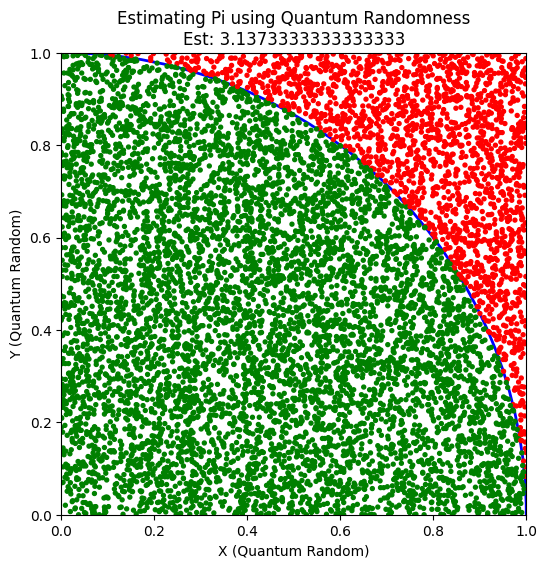

In [ ]:
# pi estimation
inside_circle = 0
print(f"Generating {NUMPOINTS} quantum random points...")
x_plot, y_plot=generate_bit_quantum(PRECISION, NUMPOINTS)
x_points = []
y_points = []
for x_, y_ in zip(x_plot, y_plot):
    x_=bin_to_dec(x_)
    y_=bin_to_dec(y_)
    x_points.append(x_)
    y_points.append(y_)
    if(x_**2 + y_**2) <=1:
        inside_circle+=1
simulated_pi=4*(inside_circle/NUMPOINTS)

print(f"--- RESULT ---")
print(f"TOTAL POINTS: {NUMPOINTS}")
print(f"QUBITS NUMBER: {PRECISION}")
print(f"POINTS INSIDE THE CIRCLE: {inside_circle}")
print(f"SIMULATED PI VALUE: {simulated_pi}")
print(f"REAL PI VALUE: {np.pi}")
print(f"ERROR : {abs(simulated_pi - np.pi)}")

# --- Visualization ---
plt.figure(figsize=(6,6))
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linewidth=2)
plt.gca().add_patch(circle)

# Plot points
colors = ['green' if (x**2 + y**2) <= 1 else 'red' for x, y in zip(x_points, y_points)]
plt.scatter(x_points, y_points, c=colors, s=8)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("X (Quantum Random)")
plt.ylabel("Y (Quantum Random)")
plt.title(f"Estimating Pi using Quantum Randomness\nEst: {simulated_pi}")
plt.show()

In [ ]:
# circuits visualisation
display(qc_a.draw('mpl'))